# Fitting On Sky Calibrations Globally

I am going to keep the comments minimal on here since the procedure is essentially exactly the same as notebook 3. I'm fitting the Joost 't Hart 2021 model for M3.

In [1]:
# DEFINING CUSTOM MM FUNCS

from pyPolCal.csv_tools import model_data
from pyPolCal.mm_registry import register_mm_function
import numpy as np
from pyPolCal.constants import wavelength_bins
from pyMuellerMat.common_mm_functions import elliptical_retarder_function , wollaston_prism_function

# Retreiving fits
wavelength_fits_dir = 'wavelength_fit_results' # path to fitted p dicts
wavelength_fits_df = model_data(wavelength_fits_dir) # saving to DataFrame
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()

@register_mm_function()
def fitted_derotator_function_12_28_2025(wavelength=500): # Only keyword arguments!
    phi_h = derotator_phi_h
    phi_45 = derotator_phi_45
    phi_r = derotator_phi_r

    # Interpolating retardance as a function of wavelength 
    phi_h_interp = np.interp(wavelength, wavelength_bins, phi_h)
    phi_45_interp = np.interp(wavelength, wavelength_bins, phi_45)
    phi_r_interp = np.interp(wavelength, wavelength_bins, phi_r)

    # using pyMuellerMat's elliptical retarder function
    return elliptical_retarder_function(phi_h_interp, phi_45_interp, phi_r_interp)

@register_mm_function()
def fitted_wollaston_function_12_28_2025(beam='o',wavelength=500): # Only keyword arguments!
    eta = wollaston_eta

    # Interpolating retardance as a function of wavelength
    eta_interp = np.interp(wavelength, wavelength_bins, eta)

    # using pyMuellerMat's elliptical retarder function
    return wollaston_prism_function(beam=beam,eta=eta_interp)

Mueller matrix function 'fitted_derotator_function_12_28_2025' is already registered. Overwriting.
Mueller matrix function 'fitted_wollaston_function_12_28_2025' is already registered. Overwriting.


/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# IMPORTING DATA

from pyPolCal.csv_tools import read_csv_physical_model_all_bins
from importlib.resources import files
from pathlib import Path

# Defining Path to my CSVs
csvdir = Path('/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_nbs/HD293396')

# Reading in data
interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir, m3=True)

In [3]:
# GENERATE MODEL
from pyPolCal.utils import generate_system_mueller_matrix

system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "fitted_wollaston_function_12_28_2025",
        "properties" : {"beam": 'o'}, 
        "tag": "internal",
        },

        "nbs_rot": {
            "type": "rotator_function",
            "properties": {"pa": 90},
            "tag": "internal",
        },
        "image_rotator" : {
        "type" : "fitted_derotator_function_12_28_2025",
        "properties" : {"delta_theta":1.384e-02}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"w_SiO2":1.638, "w_MgF2":1.28, "delta_theta": -3.168e-02},
            "tag": "internal",
        },

        "altitude_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        "M3" : {
            "type" : "SUBARU_M3_function",
            "properties" : {"delta_theta":0},
            "tag": "internal",
        },

        "parang_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        },
}
system_mm = generate_system_mueller_matrix(system_dict)
system_mm.evaluate()

array([[ 0.48902582, -0.48857441,  0.00881718,  0.01906714],
       [ 0.48902582, -0.48857441,  0.00881718,  0.01906714],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [4]:
# DEFINE STARTING GUESSES AND BOUNDS

m1, b1, m2, b2 = (1.94073,13.69728,2.07958,13.88817) # from old MCMC
p0_dict = {
    "M3":{"m1": m1,
    "b1": b1,
    "m2": m2,
    "b2": b2
    }
}
m1_bounds = (0.5*m1, 2*m1)
m2_bounds = (0.5*m2, 2*m2)
b1_bounds = (0.5*b1, 2*b1)
b2_bounds = (0.5*b2, 2*b2)
boundslist = [m1_bounds, b1_bounds, m2_bounds, b2_bounds]


In [5]:
# MINIMIZE

from pyPolCal.fitting import minimize_system_mueller_matrix
from pyPolCal.utils import process_dataset, process_model, process_errors

result_min, logl_min=minimize_system_mueller_matrix(p0_dict,system_mm,interleaved_values_all,
                               configuration_list_all,errors= interleaved_stds_all, s_in=[1,0,0,0],process_errors = process_errors,process_dataset=process_dataset,
                               process_model=process_model,include_sums=False,
                               bounds=boundslist,mode='minimize')
print(result_min)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -5260.963969832357
        x: [ 2.059e+00  1.439e+01  1.491e+00  1.226e+01]
      nit: 21
      jac: [-2.827e+01  5.607e+00  1.002e+02 -9.266e+00]
     nfev: 200
     njev: 40
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


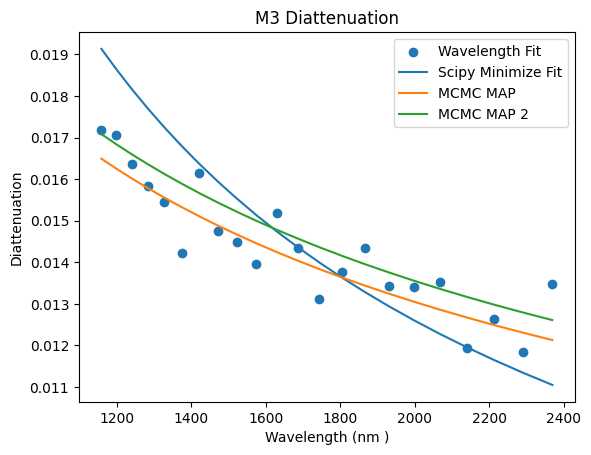

In [16]:
# Plotting against wavelength fits
from pyPolCal.csv_tools import model_data
import matplotlib.pyplot as plt
from pyMuellerMat.physical_models.charis_physical_models import * # Joost 't Hart M3 Model
dir = 'wavelength_fit_results_on_sky'
df = model_data(dir)
plt.scatter(wavelength_bins, df['M3_epsilon'], label='Wavelength Fit')
plt.plot(wavelength_bins, M3_diattenuation(wavelength_bins, m1=2.059, b1=14.39, m2=1.491, b2=12.26), label='Scipy Minimize Fit')
plt.plot(wavelength_bins, M3_diattenuation(wavelength_bins, m1=2.01, b1=10.04, m2=0.86, b2=8.67), label='MCMC MAP')
plt.plot(wavelength_bins, M3_diattenuation(wavelength_bins, m1=5.1, b1=27.12, m2=0.85, b2=8.58), label='MCMC MAP 2')
plt.xlabel("Wavelength (nm )")
plt.ylabel("Diattenuation")
plt.title("M3 Diattenuation")
plt.legend()

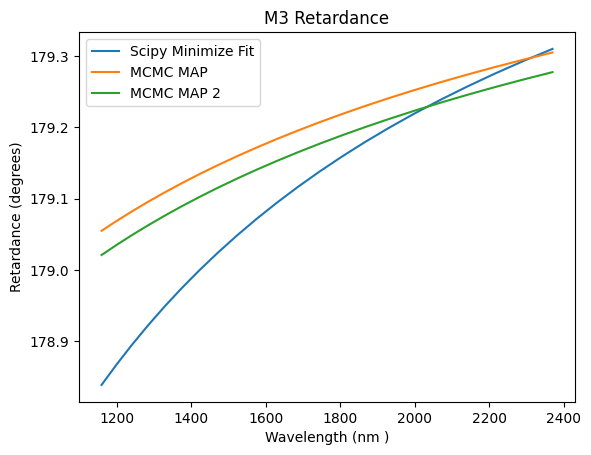

In [20]:
m3_retardance_1 = M3_retardance(wavelength_bins, m1=2.059, b1=14.39, m2=1.491, b2=12.26)
m3_retardance_2 = M3_retardance(wavelength_bins, m1=2.01, b1=10.04, m2=0.86, b2=8.67)
m3_retardance_3 = M3_retardance(wavelength_bins, m1=5.1, b1=27.12, m2=0.85, b2=8.58)
m3_retardance_1 = np.rad2deg(m3_retardance_1)
m3_retardance_2 = np.rad2deg(m3_retardance_2)
m3_retardance_3 = np.rad2deg(m3_retardance_3)
plt.plot(wavelength_bins,m3_retardance_1, label='Scipy Minimize Fit')
plt.plot(wavelength_bins,m3_retardance_2, label='MCMC MAP')
plt.plot(wavelength_bins,m3_retardance_3, label='MCMC MAP 2')
plt.xlabel("Wavelength (nm )")
plt.ylabel("Retardance (degrees)")
plt.title("M3 Retardance")
plt.legend()

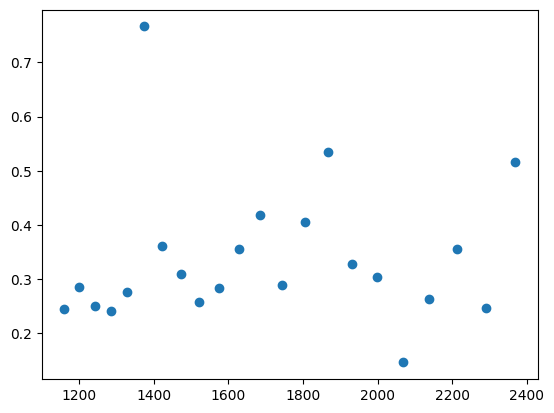

In [8]:
# CALCULATE S_ABS

from pyPolCal.fitting import calc_s_res_global
import matplotlib.pyplot as plt
m1, b1, m2, b2 = (2.059,14.39,1.491,12.26)
p0_dict = {
    "M3":
    {"m1": m1,
    "b1": b1,
    "m2": m2,
    "b2": b2
    }
}
s_abs = calc_s_res_global(csvdir, system_dict, p0_dict,number_of_fitted_params=4,m3=True)
plt.scatter(wavelength_bins, s_abs)

In [16]:
with open('s_abs.txt','w') as f:
    for sa in s_abs:
        f.write(f"{sa}\n")